# Experiment 2 Analysis (updated)
Includes heatmaps for Persistence Index and Motivation Gap.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH=Path("./experiments/e2-duration/table.csv")
df=pd.read_csv(CSV_PATH, skiprows=6)


In [3]:
metric_map={
'choice-rate "high-salience" "reward"':"reward_choice_rate",
'persistence "high-salience"':"persistence",
'persistence-index "high-salience"':"persistence_index",
'mean-intrinsic-motivation "high-salience"':"intrinsic_motivation",
'mean-habit "high-salience"':"habit_strength",
'high-reward-crowding-out-effect':"motivation_gap",
}
df=df.rename(columns=metric_map)


## Heatmap: Persistence Index

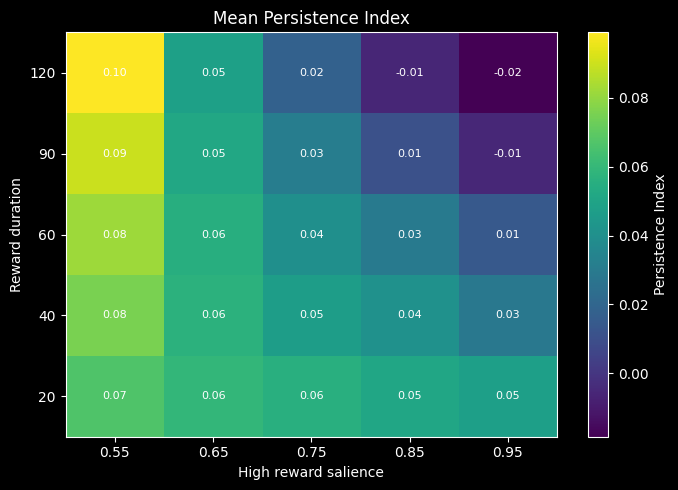

In [4]:
pivot=df.pivot_table(index="reward-duration",columns="high-reward-salience",
values="persistence_index",aggfunc="mean")
plt.figure(figsize=(7,5))
plt.imshow(pivot.values,aspect="auto",origin="lower")
plt.xticks(range(len(pivot.columns)),[f"{c:.2f}" for c in pivot.columns])
plt.yticks(range(len(pivot.index)),pivot.index)
plt.xlabel("High reward salience")
plt.ylabel("Reward duration")
plt.title("Mean Persistence Index")
plt.colorbar(label="Persistence Index")
for i,row in enumerate(pivot.values):
    for j,v in enumerate(row):
        plt.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=8)
plt.tight_layout()
plt.show()


## Heatmap: Motivation Gap vs Control

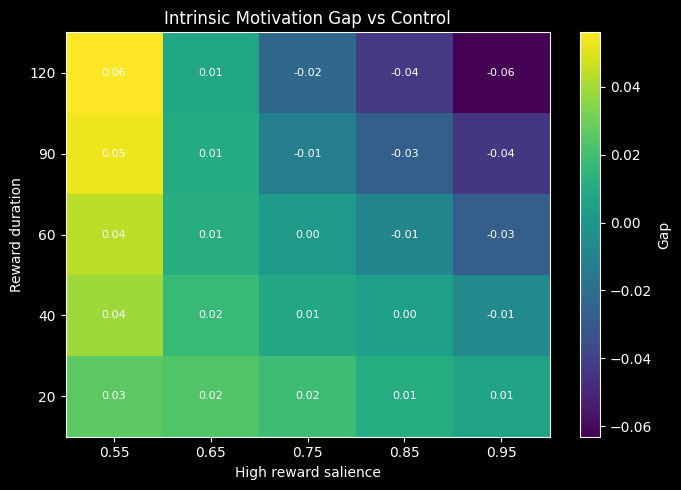

In [5]:
pivot=df.pivot_table(index="reward-duration",columns="high-reward-salience",
values="motivation_gap",aggfunc="mean")
plt.figure(figsize=(7,5))
plt.imshow(pivot.values,aspect="auto",origin="lower")
plt.xticks(range(len(pivot.columns)),[f"{c:.2f}" for c in pivot.columns])
plt.yticks(range(len(pivot.index)),pivot.index)
plt.xlabel("High reward salience")
plt.ylabel("Reward duration")
plt.title("Intrinsic Motivation Gap vs Control")
plt.colorbar(label="Gap")
for i,row in enumerate(pivot.values):
    for j,v in enumerate(row):
        plt.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=8)
plt.tight_layout()
plt.show()


## Updated conclusions

1. Reward magnitude and duration jointly determine the outcome; neither factor alone explains persistence.
2. Longer campaigns strengthen habit formation, but only while reward salience remains moderate.
3. High reward salience combined with long duration produces the strongest decline in intrinsic motivation.
4. The Persistence Index heatmap identifies a ridge of near-optimal configurations rather than a single best parameter.
5. The Motivation Gap heatmap shows a transition from positive/neutral values to negative values as both reward salience and duration increase, indicating the onset of crowding-out.
6. These heatmaps support the use of BehaviorSearch: instead of maximizing reward magnitude, the optimization problem should search for configurations that maximize Persistence Index while constraining Motivation Gap to remain non-negative.